In [ ]:
text = '''Machine learning is the study of computer algorithms that \
improve automatically through experience. It is seen as a \
subset of artificial intelligence. Machine learning algorithms \
build a mathematical model based on sample data, known as \
training data, in order to make predictions or decisions without \
being explicitly programmed to do so. Machine learning algorithms \
are used in a wide variety of applications, such as email filtering \
and computer vision, where it is difficult or infeasible to develop \
conventional algorithms to perform the needed tasks.'''

In [ ]:
import re
# 將段落拆解成單詞
def tokenize(text):
    pattern = re.compile(r'[A-Za-z]+[\w^\']*|[\w^\']*[A-Za-z]+[\w^\']*')
    return pattern.findall(text.lower())

tokens = tokenize(text)
tokens

['machine',
 'learning',
 'is',
 'the',
 'study',
 'of',
 'computer',
 'algorithms',
 'that',
 'improve',
 'automatically',
 'through',
 'experience',
 'it',
 'is',
 'seen',
 'as',
 'a',
 'subset',
 'of',
 'artificial',
 'intelligence',
 'machine',
 'learning',
 'algorithms',
 'build',
 'a',
 'mathematical',
 'model',
 'based',
 'on',
 'sample',
 'data',
 'known',
 'as',
 'training',
 'data',
 'in',
 'order',
 'to',
 'make',
 'predictions',
 'or',
 'decisions',
 'without',
 'being',
 'explicitly',
 'programmed',
 'to',
 'do',
 'so',
 'machine',
 'learning',
 'algorithms',
 'are',
 'used',
 'in',
 'a',
 'wide',
 'variety',
 'of',
 'applications',
 'such',
 'as',
 'email',
 'filtering',
 'and',
 'computer',
 'vision',
 'where',
 'it',
 'is',
 'difficult',
 'or',
 'infeasible',
 'to',
 'develop',
 'conventional',
 'algorithms',
 'to',
 'perform',
 'the',
 'needed',
 'tasks']

In [ ]:
len(tokens)

84

In [ ]:
# 將token轉換成唯一的數字代碼(在後面程式做為查表使用)
def mapping(tokens):
    word_to_id = {}
    id_to_word = {}

    for i, token in enumerate(set(tokens)):
        word_to_id[token] = i
        id_to_word[i] = token

    return word_to_id, id_to_word

word_to_id, id_to_word = mapping(tokens)

In [ ]:
word_to_id

{'decisions': 0,
 'filtering': 1,
 'are': 2,
 'infeasible': 3,
 'study': 4,
 'so': 5,
 'or': 6,
 'learning': 7,
 'tasks': 8,
 'a': 9,
 'sample': 10,
 'known': 11,
 'programmed': 12,
 'seen': 13,
 'used': 14,
 'experience': 15,
 'as': 16,
 'to': 17,
 'computer': 18,
 'of': 19,
 'perform': 20,
 'is': 21,
 'the': 22,
 'difficult': 23,
 'needed': 24,
 'model': 25,
 'variety': 26,
 'such': 27,
 'and': 28,
 'based': 29,
 'mathematical': 30,
 'artificial': 31,
 'in': 32,
 'email': 33,
 'being': 34,
 'training': 35,
 'wide': 36,
 'through': 37,
 'without': 38,
 'improve': 39,
 'explicitly': 40,
 'on': 41,
 'subset': 42,
 'machine': 43,
 'build': 44,
 'intelligence': 45,
 'do': 46,
 'applications': 47,
 'make': 48,
 'algorithms': 49,
 'order': 50,
 'conventional': 51,
 'automatically': 52,
 'develop': 53,
 'it': 54,
 'that': 55,
 'data': 56,
 'where': 57,
 'vision': 58,
 'predictions': 59}

In [ ]:
import numpy as np
np.random.seed(42)
def concat(*iterables):
    for iterable in iterables:
        yield from iterable

def one_hot_encode(id, vocab_size):
    res = [0] * vocab_size
    res[id] = 1
    return res

In [ ]:
# 產生訓練資料
def generate_training_data(tokens, word_to_id, window):
    X = []
    y = []
    n_tokens = len(tokens)

    for i in range(n_tokens):
        idx = concat(
            range(max(0, i - window), i),
            range(i, min(n_tokens, i + window + 1))
        )
        for j in idx:
            if i == j:
                continue
            X.append(one_hot_encode(word_to_id[tokens[i]], len(word_to_id)))
            y.append(one_hot_encode(word_to_id[tokens[j]], len(word_to_id)))

    return np.asarray(X), np.asarray(y)

In [ ]:
X, y = generate_training_data(tokens, word_to_id, 3)

In [ ]:
def init_network(vocab_size, n_embedding):
    model = {
        "w1": np.random.randn(vocab_size, n_embedding),
        "w2": np.random.randn(n_embedding, vocab_size)
    }
    return model

In [ ]:
model = init_network(len(word_to_id), 10)

In [ ]:
def softmax(X):
    res = []
    for x in X:
        exp = np.exp(x)
        res.append(exp / exp.sum())
    return res

def forward(model, X, return_cache=True):
    cache = {}

    cache["a1"] = X @ model["w1"]
    cache["a2"] = cache["a1"] @ model["w2"]
    cache["z"] = softmax(cache["a2"])

    if not return_cache:
        return cache["z"]
    return cache

In [ ]:
def cross_entropy(z, y):
    return - np.sum(np.log(z) * y)

def backward(model, X, y, alpha):
    cache  = forward(model, X)
    da2 = cache["z"] - y
    dw2 = cache["a1"].T @ da2
    da1 = da2 @ model["w2"].T
    dw1 = X.T @ da1
    assert(dw2.shape == model["w2"].shape)
    assert(dw1.shape == model["w1"].shape)
    model["w1"] -= alpha * dw1
    model["w2"] -= alpha * dw2
    return cross_entropy(cache["z"], y)

<ipython-input-13-30907dc27f77>:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


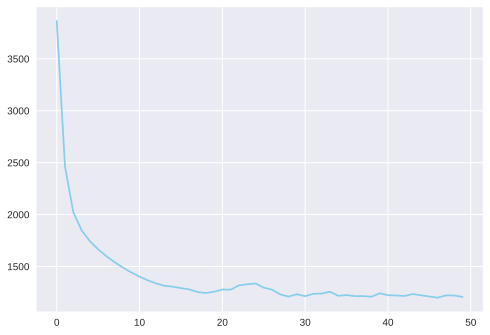

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

plt.style.use("seaborn")

n_iter = 50
learning_rate = 0.05

history = [backward(model, X, y, learning_rate) for _ in range(n_iter)]

plt.plot(range(len(history)), history, color="skyblue")
plt.show()


In [ ]:
learning = one_hot_encode(word_to_id["learning"], len(word_to_id))
result = forward(model, [learning], return_cache=False)[0]
result

array([2.96123848e-04, 5.23573793e-05, 5.66640307e-02, 1.19979899e-04,
       2.55750808e-02, 5.01337818e-02, 1.26148412e-04, 4.01229639e-02,
       6.43565154e-03, 3.35015475e-02, 3.80463449e-04, 1.02755771e-03,
       2.09267112e-03, 1.97133666e-03, 2.52985140e-02, 4.38891100e-03,
       1.40232073e-02, 2.15918075e-02, 8.50659537e-03, 1.32134956e-02,
       1.69100173e-03, 5.45201046e-02, 3.12522691e-02, 1.53443460e-04,
       1.06817731e-03, 2.53962467e-03, 1.83097200e-03, 1.68275725e-04,
       3.60475617e-05, 5.77867312e-04, 3.79418068e-03, 4.77288211e-02,
       2.21936870e-04, 7.79065838e-06, 5.92796304e-05, 3.47627467e-04,
       6.40048792e-03, 6.10566670e-03, 8.49135030e-05, 8.33157059e-04,
       9.10961723e-05, 1.49972997e-03, 7.36492141e-03, 2.93448881e-01,
       4.02970924e-02, 9.89893575e-02, 6.65173984e-02, 3.69694418e-04,
       4.21909453e-04, 1.84022710e-02, 9.57073879e-04, 3.08767195e-04,
       3.32452418e-03, 1.74278676e-05, 1.81481821e-04, 1.71995755e-03,
      

In [ ]:
def get_embedding(model, word):
    try:
        idx = word_to_id[word]
    except KeyError:
        print("`word` not in corpus")
    one_hot = one_hot_encode(idx, len(word_to_id))
    return forward(model, one_hot)["a1"]

print(get_embedding(model, "machine"))

[ 1.26700243  0.02621869  0.27084308  1.0994886   0.26638842  1.19482294
  0.85444113 -0.35225334 -1.15942713  0.29579277]


In [ ]:
for word in (id_to_word[id] for id in np.argsort(result)[::-1]):
  print(word, ':', get_embedding(model, word))

machine : [ 1.26700243  0.02621869  0.27084308  1.0994886   0.26638842  1.19482294
  0.85444113 -0.35225334 -1.15942713  0.29579277]
intelligence : [ 0.47656009  1.52450921  0.24064021  0.91399838 -0.11061157  1.18261387
 -0.4017077   0.26875516 -1.0980019  -1.27471033]
do : [ 0.87738442 -1.13102801 -1.78270515 -0.3479773   0.53331022  1.43919372
 -0.12295942 -1.14997702 -0.33955504 -0.89537299]
are : [ 1.56558467  1.35191734 -0.6071222  -0.79699139 -0.0260862  -0.16494321
 -1.22128531 -0.87248127 -0.39499524 -0.75042578]
is : [ 0.87394939 -0.10608733 -0.39532945 -0.09562737 -0.32567575  0.46742498
 -0.55954718  0.97922487  0.26658823 -2.15420726]
so : [ 0.61876802  0.05876201 -1.32330215  0.91032809  0.50703351  1.50837581
 -1.2941778  -0.43923222 -0.16793204  0.14640068]
artificial : [-0.38350824  1.46110749  0.16889568  0.42240532  0.18887681  1.40936065
 -0.20650831 -0.6618465  -1.21524836 -1.49636687]
build : [ 0.17980279  1.20927546 -1.71988748  0.59401842 -0.44666391  1.0493472
